Starting Real Field TOMATO Disease Classification Training with Class Balancing...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully
Using dataset path: /content/drive/MyDrive/Real_Field_Tomato_Dataset
Random seed: 454546

Analyzing Real Field Tomato Dataset...
  - tomato_bacterial_spot: 138 images
  - tomato_early_blight: 160 images
  - tomato_healthy_leaf: 807 images
  - tomato_late_blight: 544 images

Total images: 1,649
Imbalance ratio: 5.85:1
Dataset is imbalanced - applying class weights

Computed Class Weights for Balancing:
  - tomato_bacterial_spot (class 0): 2.987
  - tomato_early_blight (class 1): 2.577
  - tomato_healthy_leaf (class 2): 0.511
  - tomato_late_blight (class 3): 0.758

Existing train/val/test splits found with 1649 total images
Using existing splits instead of creating new ones...
  - train/tomato_bacterial_spot: 96 images
  - train/tomato_early_bli

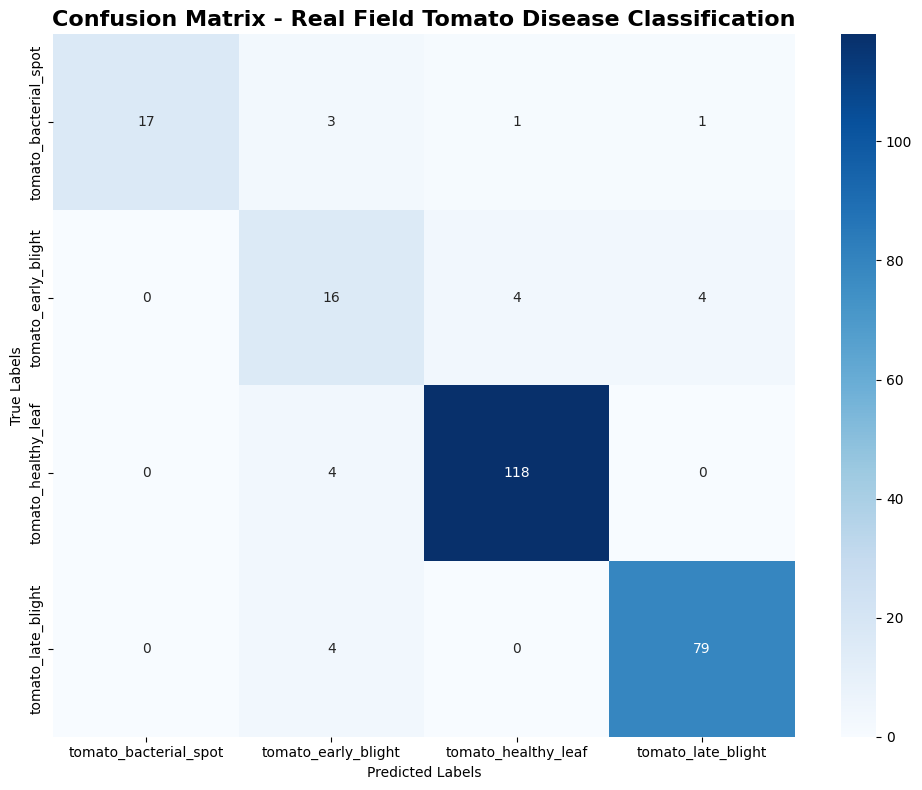

Training history saved to Google Drive


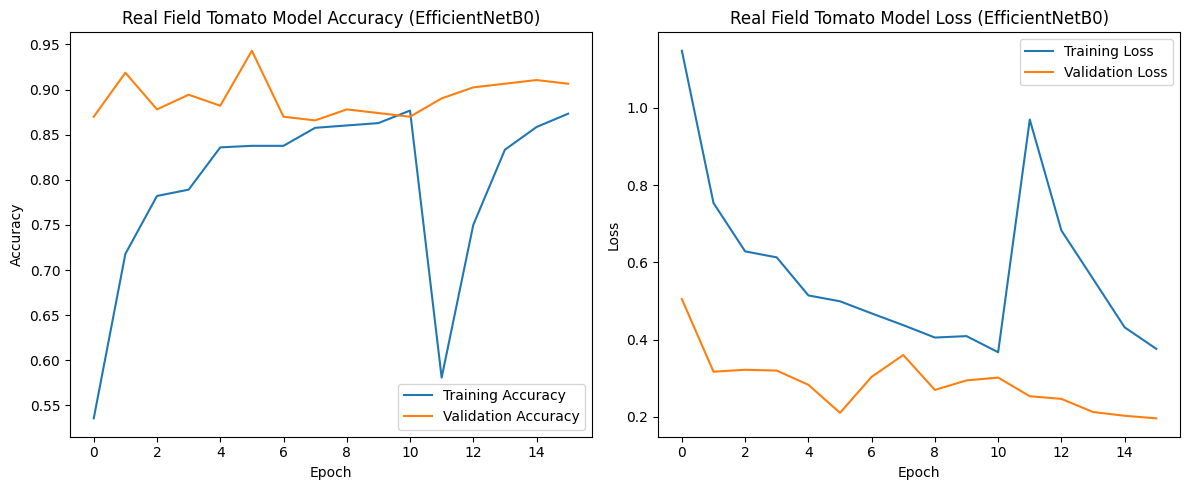


REAL FIELD TOMATO DISEASE CLASSIFICATION - FINAL REPORT
Dataset: Real Field Tomato Dataset
Strategy: EfficientNetB0 + SGD + Class Balancing
Class Weights Applied: YES (sklearn balanced method)
Data Augmentation: Realistic Agricultural (training only)
Random Seed: 454546
Dataset Balance Status: Imbalanced (ratio: 5.85)
Total Images: 1,649
Training Time: 47.1 minutes
Memory Used: 2138.89 MB
Epochs Trained: 16
Test Accuracy: 0.9163 +/- 0.0174
Precision (weighted): 0.9216
Recall (weighted): 0.9163
F1 Score (weighted): 0.9175
95% CI: [0.8805, 0.9482]

------------------------------------------------------------
CLASS DISTRIBUTION
------------------------------------------------------------
tomato_bacterial_spot    :  138 total (weight: 2.987)
tomato_early_blight      :  160 total (weight: 2.577)
tomato_healthy_leaf      :  807 total (weight: 0.511)
tomato_late_blight       :  544 total (weight: 0.758)

------------------------------------------------------------
MODEL READY FOR DEPLOYMENT


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# New Imports
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import SGD #Adam, Nadam, Adagrad, RMSProp, SGD
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import shutil
import platform
import psutil
import datetime
import pandas as pd
import csv
from collections import Counter
import glob

print("Starting Real Field TOMATO Disease Classification Training with Class Balancing...")
print("="*80)

# Mount Google Drive
from google.colab import drive
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully")
    USE_DRIVE = True
except Exception as e:
    print(f"Google Drive mount failed: {e}")
    print("Will continue without Google Drive. Results will only be saved locally.")
    USE_DRIVE = False

# =======================
# Configuration
# =======================
DATASET_PATH = "/content/drive/MyDrive/Real_Field_Tomato_Dataset" # <-- your folder with 1 subfolder per class
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_SIZE = 0.7
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 454546 # <-- updated seed


# Set random seeds for reproducibility
seed = RANDOM_STATE
np.random.seed(seed)
tf.random.set_seed(seed)

print(f"Using dataset path: {DATASET_PATH}")
print(f"Random seed: {seed}")

# Check if dataset exists
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at: {DATASET_PATH}\nPut your folder in Drive or update DATASET_PATH.")

def analyze_dataset_and_compute_weights():
    """Analyze the Real Field Tomato Dataset and compute class weights"""
    print(f"\nAnalyzing Real Field Tomato Dataset...")

    class_info = {}
    total_images = 0

    # Look for actual class folders (skip train/validation/test folders)
    excluded_folders = {'train', 'validation', 'test'}

    # Analyze each class folder
    for class_folder in sorted(os.listdir(DATASET_PATH)):
        class_path = os.path.join(DATASET_PATH, class_folder)

        # Skip if it's a split folder or not a directory
        if not os.path.isdir(class_path) or class_folder in excluded_folders:
            continue

        # Count images in this class (support common extensions)
        image_files = []
        for ext in ('*.jpg','*.jpeg','*.png','*.bmp','*.JPG','*.JPEG','*.PNG','*.BMP'):
            image_files += glob.glob(os.path.join(class_path, ext))

        if len(image_files) > 0:
            class_info[class_folder] = len(image_files)
            total_images += len(image_files)
            print(f"  - {class_folder}: {len(image_files)} images")

    if len(class_info) == 0:
        raise ValueError("No class folders with images found! Expected one folder per class in DATASET_PATH.")

    print(f"\nTotal images: {total_images:,}")

    # Calculate imbalance ratio
    class_counts = list(class_info.values())
    if class_counts and min(class_counts) > 0:
        imbalance_ratio = max(class_counts) / min(class_counts)
        print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")
        if imbalance_ratio > 2.0:
            print("Dataset is imbalanced - applying class weights")
        else:
            print("Dataset is reasonably balanced")
    else:
        raise ValueError("Some classes have zero images! Please check your dataset.")

    # Compute class weights using sklearn's balanced method
    class_names = sorted(list(class_info.keys()))

    # Create label arrays for sklearn
    y_for_weights = []
    for i, class_name in enumerate(class_names):
        count = class_info[class_name]
        y_for_weights.extend([i] * count)

    y_for_weights = np.array(y_for_weights)
    classes = np.arange(len(class_names))

    balanced_weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_for_weights
    )

    class_weights = {i: float(weight) for i, weight in enumerate(balanced_weights)}

    print(f"\nComputed Class Weights for Balancing:")
    for i, (class_name, weight) in enumerate(zip(class_names, balanced_weights)):
        print(f"  - {class_name} (class {i}): {weight:.3f}")

    return class_info, class_names, class_weights, imbalance_ratio

def create_train_val_test_splits(data_dir, class_info, train_size=0.7, val_size=0.15, test_size=0.15):
    """Create stratified train, validation, and test splits"""
    assert abs((train_size + val_size + test_size) - 1.0) < 1e-6, "Split sizes must sum to 1.0"

    # Check if splits already exist and contain data
    train_path = os.path.join(data_dir, 'train')
    val_path = os.path.join(data_dir, 'validation')
    test_path = os.path.join(data_dir, 'test')

    splits_exist = all(os.path.exists(path) for path in [train_path, val_path, test_path])

    if splits_exist:
        # Check if splits contain actual images
        total_images_in_splits = 0
        for split_path in [train_path, val_path, test_path]:
            if os.path.exists(split_path):
                for class_folder in os.listdir(split_path):
                    class_path = os.path.join(split_path, class_folder)
                    if os.path.isdir(class_path):
                        images = [f for f in os.listdir(class_path)
                                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
                        total_images_in_splits += len(images)

        if total_images_in_splits > 0:
            print(f"\nExisting train/val/test splits found with {total_images_in_splits} total images")
            print("Using existing splits instead of creating new ones...")

            # Count existing splits
            split_stats = {'train': {}, 'validation': {}, 'test': {}}
            for split_name, split_path in [('train', train_path), ('validation', val_path), ('test', test_path)]:
                if os.path.exists(split_path):
                    for class_folder in os.listdir(split_path):
                        class_path = os.path.join(split_path, class_folder)
                        if os.path.isdir(class_path):
                            images = [f for f in os.listdir(class_path)
                                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
                            split_stats[split_name][class_folder] = len(images)
                            print(f"  - {split_name}/{class_folder}: {len(images)} images")

            return split_stats

    print(f"\nCreating NEW stratified train/validation/test splits...")

    # Create directories for splits
    splits = ['train', 'validation', 'test']
    for split in splits:
        split_dir = os.path.join(data_dir, split)
        if os.path.exists(split_dir):
            shutil.rmtree(split_dir)
        os.makedirs(split_dir, exist_ok=True)

    split_stats = {'train': {}, 'validation': {}, 'test': {}}

    # Process each class directory
    for class_name in class_info.keys():
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        # Create class directories in split directories
        for split in splits:
            os.makedirs(os.path.join(data_dir, split, class_name), exist_ok=True)

        # Get all image files
        image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.JPG', '*.JPEG', '*.PNG', '*.BMP']
        images = []
        for ext in image_extensions:
            images.extend(glob.glob(os.path.join(class_dir, ext)))

        if len(images) == 0:
            print(f"Warning: No images found in {class_dir}")
            continue

        # Shuffle images for random splits
        rng = np.random.default_rng(seed)
        rng.shuffle(images)

        # Calculate split indices
        total_count = len(images)
        train_count = int(total_count * train_size)
        val_count = int(total_count * val_size)

        # Split images
        train_images = images[:train_count]
        val_images = images[train_count:train_count + val_count]
        test_images = images[train_count + val_count:]

        # Copy images to respective directories
        for img_list, split_name in [(train_images, 'train'),
                                     (val_images, 'validation'),
                                     (test_images, 'test')]:
            for img in img_list:
                dest_path = os.path.join(data_dir, split_name, class_name, os.path.basename(img))
                shutil.copy2(img, dest_path)

        # Record statistics
        split_stats['train'][class_name] = len(train_images)
        split_stats['validation'][class_name] = len(val_images)
        split_stats['test'][class_name] = len(test_images)

        print(f"  - {class_name}: {len(train_images)} train, {len(val_images)} val, {len(test_images)} test")

    return split_stats

def analyze_splits(data_dir, split_stats):
    """Analyze and display split statistics"""
    print(f"\nSPLIT ANALYSIS")
    print("="*60)

    class_names = list(split_stats['train'].keys()) if 'train' in split_stats else []

    if not class_names:
        print("No classes found in splits!")
        return {'train': 0, 'validation': 0, 'test': 0, 'total': 0}

    # Display statistics table
    print(f"{'Class':<25} {'Train':<8} {'Val':<8} {'Test':<8} {'Total':<8}")
    print("-" * 65)

    totals = {'train': 0, 'validation': 0, 'test': 0, 'total': 0}

    for class_name in class_names:
        train_count = split_stats['train'].get(class_name, 0)
        val_count = split_stats['validation'].get(class_name, 0)
        test_count = split_stats['test'].get(class_name, 0)
        total_count = train_count + val_count + test_count

        print(f"{class_name:<25} {train_count:<8} {val_count:<8} {test_count:<8} {total_count:<8}")

        totals['train'] += train_count
        totals['validation'] += val_count
        totals['test'] += test_count
        totals['total'] += total_count

    print("-" * 65)
    print(f"{'TOTAL':<25} {totals['train']:<8} {totals['validation']:<8} {totals['test']:<8} {totals['total']:<8}")

    # Calculate percentages
    print(f"\nSplit Percentages:")
    if totals['total'] > 0:
        train_pct = (totals['train'] / totals['total']) * 100
        val_pct = (totals['validation'] / totals['total']) * 100
        test_pct = (totals['test'] / totals['total']) * 100

        print(f"  - Train: {train_pct:.1f}%")
        print(f"  - Validation: {val_pct:.1f}%")
        print(f"  - Test: {test_pct:.1f}%")

    return totals

# Get system information
def get_system_info():
    system_info = {
        'seed_used': seed,
        'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'os': platform.platform(),
        'cpu_model': platform.processor(),
        'cpu_cores': os.cpu_count(),
        'gpu': 'No GPU detected',
        'tensorflow_version': tf.__version__,
        'cuda_available': str(len(tf.config.list_physical_devices('GPU')) > 0)
    }

    # Check for GPU
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        system_info['gpu'] = tf.test.gpu_device_name()

    return system_info

# Function to calculate FLOPs for model training
def calculate_training_flops(model, train_generator, total_epochs, num_train_samples):
    """Calculate approximate FLOPs for model training"""
    total_params = model.count_params()

    # Rough estimation:
    forward_flops = 2 * total_params
    backward_flops = 4 * total_params
    total_flops_per_step = forward_flops + backward_flops

    # Calculate total training FLOPs
    batch_size = train_generator.batch_size
    steps_per_epoch = max(1, num_train_samples // batch_size)
    total_steps = steps_per_epoch * total_epochs

    total_training_flops = total_flops_per_step * total_steps

    return {
        'forward_flops_per_sample': int(forward_flops),
        'backward_flops_per_sample': int(backward_flops),
        'total_flops_per_step': int(total_flops_per_step),
        'steps_per_epoch': int(steps_per_epoch),
        'total_steps': int(total_steps),
        'total_training_flops': int(total_training_flops),
        'total_training_gflops': total_training_flops / 1e9
    }

# =======================
# Pipeline
# =======================
start_time = time.time()
system_info = get_system_info()

# Step 1: Analyze dataset and compute class weights
class_info, class_names, class_weights, imbalance_ratio = analyze_dataset_and_compute_weights()

# Step 2: Create train/val/test splits
split_stats = create_train_val_test_splits(DATASET_PATH, class_info, TRAIN_SIZE, VAL_SIZE, TEST_SIZE)

# Step 3: Analyze splits
totals = analyze_splits(DATASET_PATH, split_stats)

# Directory paths for data generators
train_dir = os.path.join(DATASET_PATH, 'train')
validation_dir = os.path.join(DATASET_PATH, 'validation')
test_dir = os.path.join(DATASET_PATH, 'test')

print(f"\nCreating data generators with realistic agricultural augmentation...")

# Training data generator with realistic field-like augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    brightness_range=[0.8, 1.2],
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.05,
    fill_mode='nearest'
)

# Validation and test generators with NO augmentation - only preprocessing
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print("Training data: Realistic agricultural augmentation applied")
print("Validation data: No augmentation - clean evaluation")
print("Test data: No augmentation - reliable performance metrics")

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=seed
)

val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=seed
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=seed
)

# Verify generators
num_classes = len(train_generator.class_indices)
print(f"\nData generators created:")
print(f"  - Classes found: {num_classes}")
print(f"  - Class indices: {train_generator.class_indices}")
print(f"  - Training samples: {train_generator.samples}")
print(f"  - Validation samples: {val_generator.samples}")
print(f"  - Test samples: {test_generator.samples}")

# Display class weights that will be applied
print(f"\nClass weights for balanced training:")
for cname, cidx in train_generator.class_indices.items():
    print(f"  - {cname}: {class_weights[cidx]:.3f}")

# Build model using EfficientNetB0
print(f"\nBuilding EfficientNetB0 model...")
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the base model layers for phase 1
for layer in base_model.layers:
    layer.trainable = False

print(f"Model created with {model.count_params():,} total parameters")

best_lr = 0.01 # Phase 1
fine_tuning_lr = 0.001 # Phase 2

print(f"\nUsing SGD optimizer with learning rates:")
print(f"  - Initial training: {best_lr}")
print(f"  - Fine-tuning: {fine_tuning_lr}")

# Compile (Phase 1) with SGD @ 0.01
model.compile(
    optimizer=SGD(learning_rate=best_lr, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Callbacks
checkpoint_path = "real_field_tomato_efficientnetb0_checkpoint.keras"
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_best_only=True, monitor='val_accuracy')

print(f"\nStarting training with class balancing...")
print(f"Phase 1: Training with frozen base model (epochs: 20)")

# Train phase 1 (base model frozen) with class weights
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    class_weight=class_weights,
    verbose=1
)

# Record phase 1 results
phase1_results = {
    'phase1_final_train_accuracy': history.history['accuracy'][-1],
    'phase1_final_val_accuracy': history.history['val_accuracy'][-1],
    'phase1_epochs': len(history.history['accuracy'])
}

print(f"\nPhase 1 Results:")
print(f"  - Final training accuracy: {phase1_results['phase1_final_train_accuracy']:.4f}")
print(f"  - Final validation accuracy: {phase1_results['phase1_final_val_accuracy']:.4f}")
print(f"  - Epochs completed: {phase1_results['phase1_epochs']}")

# Fine-tuning decision
train_accuracy = history.history['accuracy'][-1]
phase2_ran = "No"
phase2_epochs = 0

if train_accuracy >= 0.8:
    print(f"\nAchieved {train_accuracy*100:.2f}% training accuracy. Starting fine-tuning phase...")
    phase2_ran = "Yes"

    # Unfreeze top layers for fine-tuning
    base_model.trainable = True
    for layer in base_model.layers[:100]:
        layer.trainable = False
    for layer in base_model.layers[100:]:
        layer.trainable = True

    # Compile with SGD @ 0.001 for fine-tuning
    model.compile(
        optimizer=SGD(learning_rate=fine_tuning_lr, momentum=0.9, nesterov=True),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )


    print(f"Phase 2: Fine-tuning unfrozen layers (epochs: 30)")
    history_fine_tune = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=30,
        callbacks=[early_stopping, reduce_lr, checkpoint],
        class_weight=class_weights,
        verbose=1
    )

    phase2_epochs = len(history_fine_tune.history['accuracy'])
    phase2_results = {
        'phase2_ran': phase2_ran,
        'phase2_final_train_accuracy': history_fine_tune.history['accuracy'][-1],
        'phase2_final_val_accuracy': history_fine_tune.history['val_accuracy'][-1],
        'phase2_epochs': phase2_epochs
    }

    combined_acc = history.history['accuracy'] + history_fine_tune.history['accuracy']
    combined_val_acc = history.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
    combined_loss = history.history['loss'] + history_fine_tune.history['loss']
    combined_val_loss = history.history['val_loss'] + history_fine_tune.history['val_loss']
    total_epochs = len(combined_acc)
else:
    print(f"\nOnly achieved {train_accuracy*100:.2f}% training accuracy, below 80% threshold. Skipping fine-tuning.")
    phase2_results = {'phase2_ran': phase2_ran, 'phase2_final_train_accuracy': None,
                      'phase2_final_val_accuracy': None, 'phase2_epochs': 0}
    combined_acc = history.history['accuracy']
    combined_val_acc = history.history['val_accuracy']
    combined_loss = history.history['loss']
    combined_val_loss = history.history['val_loss']
    total_epochs = len(combined_acc)

# Time
train_time_seconds = time.time() - start_time
train_time_minutes = train_time_seconds / 60
print(f"\nTraining completed in {train_time_minutes:.1f} minutes")

# FLOPs
print(f"\nCalculating FLOPs for model training...")
num_train_samples = sum(split_stats['train'].values()) if 'train' in split_stats else 0
flops_info = calculate_training_flops(model, train_generator, total_epochs, num_train_samples)
for k, v in flops_info.items():
    print(f"{k}: {v}")

# Evaluate on test data
print(f"\nEvaluating on test data...")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

# Inference timing
print(f"\nMeasuring inference time performance...")
single_image_times = []
test_generator.reset()
timing_batches = min(10, len(test_generator))
for i, (batch_x, _) in enumerate(test_generator):
    if i >= timing_batches:
        break
    single_image = batch_x[0:1]
    start_inference = time.time()
    _ = model.predict(single_image, verbose=0)
    end_inference = time.time()
    single_image_times.append(end_inference - start_inference)

avg_single_inference_time = np.mean(single_image_times) if single_image_times else 0.0
print(f"Inference time (single image, avg): {avg_single_inference_time*1000:.2f} ms")

# Predictions & metrics
print(f"\nGenerating predictions for detailed analysis...")
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_labels = test_generator.classes

min_length = min(len(predicted_classes), len(true_labels))
predicted_classes = predicted_classes[:min_length]
true_labels = true_labels[:min_length]

print(f"Generated {min_length} predictions for evaluation")

try:
    precision = precision_score(true_labels, predicted_classes, average='weighted', zero_division=0)
    recall = recall_score(true_labels, predicted_classes, average='weighted', zero_division=0)
    f1 = f1_score(true_labels, predicted_classes, average='weighted', zero_division=0)
    cm = confusion_matrix(true_labels, predicted_classes)

    from tensorflow.keras.utils import to_categorical
    true_labels_one_hot = to_categorical(true_labels, num_classes=num_classes)
    auc_ovr = roc_auc_score(true_labels_one_hot, predictions[:len(true_labels)], multi_class='ovr')

    precision_per_class = precision_score(true_labels, predicted_classes, average=None, zero_division=0)
    recall_per_class = recall_score(true_labels, predicted_classes, average=None, zero_division=0)
    f1_per_class = f1_score(true_labels, predicted_classes, average=None, zero_division=0)

    print(f"\nPER-CLASS PERFORMANCE:")
    print("-" * 50)
    print(f"{'Class':<25} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
    print("-" * 50)

    actual_class_names = [name for name, idx in sorted(train_generator.class_indices.items(), key=lambda x: x[1])]
    for i, class_name in enumerate(actual_class_names):
        if i < len(precision_per_class):
            print(f"{class_name:<25} {precision_per_class[i]:<10.4f} {recall_per_class[i]:<10.4f} {f1_per_class[i]:<10.4f}")

    print(f"\nClassification Report:")
    print(classification_report(true_labels, predicted_classes, target_names=actual_class_names, zero_division=0))

except Exception as e:
    print(f"Error calculating detailed metrics: {e}")
    precision = recall = f1 = test_accuracy
    precision_per_class = recall_per_class = f1_per_class = [precision] * num_classes
    cm = np.eye(num_classes)
    auc_ovr = np.nan
    actual_class_names = [f"class_{i}" for i in range(num_classes)]

# Plots
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=actual_class_names, yticklabels=actual_class_names)
plt.title('Confusion Matrix - Real Field Tomato Disease Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.savefig('real_field_tomato_efficientnetb0_confusion_matrix.png')
if USE_DRIVE:
    try:
        plt.savefig('/content/drive/MyDrive/real_field_tomato_efficientnetb0_confusion_matrix.png')
        print("Confusion matrix saved to Google Drive")
    except Exception as e:
        print(f"Failed to save confusion matrix to Google Drive: {e}")
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(combined_acc, label='Training Accuracy')
plt.plot(combined_val_acc, label='Validation Accuracy')
plt.title('Real Field Tomato Model Accuracy (EfficientNetB0)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(combined_loss, label='Training Loss')
plt.plot(combined_val_loss, label='Validation Loss')
plt.title('Real Field Tomato Model Loss (EfficientNetB0)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('real_field_tomato_efficientnetb0_training_history.png')
if USE_DRIVE:
    try:
        plt.savefig('/content/drive/MyDrive/real_field_tomato_efficientnetb0_training_history.png')
        print("Training history saved to Google Drive")
    except Exception as e:
        print(f"Failed to save training history to Google Drive: {e}")
plt.show()

# Bootstrap CI for accuracy
n_bootstrap = 1000
bootstrap_accuracies = []
rng = np.random.default_rng(seed)
for _ in range(n_bootstrap):
    indices = rng.integers(0, len(true_labels), size=len(true_labels))
    resampled_predictions = predicted_classes[indices]
    resampled_true_labels = true_labels[indices]
    accuracy = np.mean(resampled_predictions == resampled_true_labels)
    bootstrap_accuracies.append(accuracy)

confidence_interval = np.percentile(bootstrap_accuracies, [2.5, 97.5])
bootstrap_std = np.std(bootstrap_accuracies)
bootstrap_mean = np.mean(bootstrap_accuracies)

# Memory usage
mem = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# Class distribution helpers
class_counts = list(class_info.values())
total_samples = sum(class_counts)
class_percentages = [(count / total_samples) * 100 for count in class_counts]
min_class_percentage = min(class_percentages)
max_class_percentage = max(class_percentages)

# Results pack
results = {
    **system_info,
    'optimizer': 'SGD',
    'base_model': 'EfficientNetB0',
    'augmentation_strategy': 'Realistic Agricultural (Training Only)',
    'learning_rate_strategy': 'Specified Learning Rates (SGD)',
    'best_learning_rate': best_lr,
    'fine_tuning_learning_rate': fine_tuning_lr,
    'class_weights_used': class_weights,
    'hyperparameter_tuning_used': False,
    'batch_size': BATCH_SIZE,
    'image_size': f'{IMG_SIZE[0]}x{IMG_SIZE[1]}',
    'training_time_seconds': train_time_seconds,
    'training_time_minutes': train_time_minutes,
    'memory_used_mb': mem,
    'epochs_trained': total_epochs,
    'test_accuracy': float(test_accuracy),
    'test_accuracy_bootstrap_mean': float(bootstrap_mean),
    'test_accuracy_bootstrap_std': float(bootstrap_std),
    'precision_weighted': float(precision),
    'recall_weighted': float(recall),
    'f1_score_weighted': float(f1),
    'auc_ovr': float(auc_ovr) if not np.isnan(auc_ovr) else None,
    'confidence_interval_lower': float(confidence_interval[0]),
    'confidence_interval_upper': float(confidence_interval[1]),
    'avg_single_inference_time_ms': float(avg_single_inference_time * 1000),
    'total_images_all_splits': int(totals['total']),
    'num_classes': int(num_classes),
    'class_imbalance_ratio': float(imbalance_ratio),
    'min_class_percentage': float(min_class_percentage),
    'max_class_percentage': float(max_class_percentage),
    'dataset_balance_status': 'Balanced' if imbalance_ratio <= 2.0 else 'Imbalanced',
    'train_images_total': int(totals['train']),
    'val_images_total': int(totals['validation']),
    'test_images_total': int(totals['test']),
    **flops_info,
    **phase1_results,
    **phase2_results
}

# Final report
print(f"\n" + "="*80)
print("REAL FIELD TOMATO DISEASE CLASSIFICATION - FINAL REPORT")
print("="*80)
print(f"Dataset: Real Field Tomato Dataset")
print(f"Strategy: EfficientNetB0 + SGD + Class Balancing")
print(f"Class Weights Applied: YES (sklearn balanced method)")
print(f"Data Augmentation: Realistic Agricultural (training only)")
print(f"Random Seed: {seed}")
print(f"Dataset Balance Status: {'Balanced' if imbalance_ratio <= 2.0 else 'Imbalanced'} (ratio: {imbalance_ratio:.2f})")
print(f"Total Images: {totals['total']:,}")
print(f"Training Time: {train_time_minutes:.1f} minutes")
print(f"Memory Used: {mem:.2f} MB")
print(f"Epochs Trained: {total_epochs}")
print(f"Test Accuracy: {test_accuracy:.4f} +/- {bootstrap_std:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 Score (weighted): {f1:.4f}")
print(f"95% CI: [{confidence_interval[0]:.4f}, {confidence_interval[1]:.4f}]")

print(f"\n" + "-"*60)
print("CLASS DISTRIBUTION")
print("-"*60)
for class_name in [name for name, _ in sorted(train_generator.class_indices.items(), key=lambda x: x[1])]:
    if class_name in split_stats['train']:
        train_count = split_stats['train'][class_name]
        val_count = split_stats['validation'][class_name]
        test_count = split_stats['test'][class_name]
        total_count = train_count + val_count + test_count
        weight = class_weights[train_generator.class_indices[class_name]]
        print(f"{class_name:<25}: {total_count:4d} total (weight: {weight:.3f})")

print(f"\n" + "-"*60)
print("MODEL READY FOR DEPLOYMENT")
print("-"*60)
print(f"Model architecture: EfficientNetB0 with custom head")
print(f"Optimizer: SGD with learning rates {best_lr} -> {fine_tuning_lr}")
print(f"Class balancing: sklearn balanced weights")
print(f"Realistic augmentation: Field-condition simulation")
print(f"Robust evaluation: Bootstrap confidence intervals")

# Save results to CSV
local_csv_filename = 'real_field_tomato_efficientnetb0_results.csv'
drive_csv_filename = '/content/drive/MyDrive/real_field_tomato_efficientnetb0_results.csv'

try:
    with open(local_csv_filename, 'w', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=results.keys())
        writer.writeheader()
        writer.writerow(results)
    print(f"\nResults saved to '{local_csv_filename}'")
except Exception as e:
    print(f"Failed to save results locally: {e}")

if USE_DRIVE:
    try:
        with open(drive_csv_filename, 'w', newline='') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=results.keys())
            writer.writeheader()
            writer.writerow(results)
        print(f"Results also saved to Google Drive: '{drive_csv_filename}'")
    except Exception as e:
        print(f"Failed to save results to Google Drive: {e}")

# Save the model
try:
    model.save('real_field_tomato_efficientnetb0_model.keras')
    print(f"\nModel saved locally as 'real_field_tomato_efficientnetb0_model.keras'")
except Exception as e:
    print(f"Failed to save model locally: {e}")

if USE_DRIVE:
    try:
        model.save('/content/drive/MyDrive/real_field_tomato_efficientnetb0_model.keras')
        print("Model also saved to Google Drive")
    except Exception as e:
        print(f"Failed to save model to Google Drive: {e}")

# Inference helper
def predict_tomato_disease(image_path, model=model,
                           class_names=[name for name, _ in sorted(train_generator.class_indices.items(), key=lambda x: x[1])]):
    """
    Predict tomato disease from an image file using the trained model.
    Returns (predicted_class, confidence_score, all_probabilities_dict)
    """
    try:
        img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)

        probs = model.predict(img_array, verbose=0)[0]
        idx = int(np.argmax(probs))
        return class_names[idx], float(probs[idx]), {class_names[i]: float(probs[i]) for i in range(len(class_names))}
    except Exception as e:
        print(f"Error making prediction: {e}")
        return None, 0.0, {}

print(f"\nExample Usage:")
print("model = tf.keras.models.load_model('real_field_tomato_efficientnetb0_model.keras')")
print("disease, confidence, all_probs = predict_tomato_disease('path/to/tomato_leaf.jpg')")
print("print(f'Predicted: {disease} ({confidence:.2%} confidence)')")